> ### **Setup & Data Load**

In [267]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from copy import deepcopy
from sklearn.impute import SimpleImputer

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

In [268]:
DATA_PATH = "cleaned_EDA_ready_timeseries.csv"
df = pd.read_csv(DATA_PATH)
df

,Country Name,Country Code,Year,GDP_current_usd,Population_total,LifeExp_years,Energy_use_kg_oil_pc,Renewable_energy_pct,CO2_total_mt,CO2_per_capita_ton
0,Albania,ALB,1970,1.578102e+09,2135479.0,65.234,813.373801,25.5,4.8450,2.268812
1,Albania,ALB,1971,1.578102e+09,2187853.0,65.896,813.373801,25.5,4.8381,2.211346
2,Albania,ALB,1972,1.578102e+09,2243126.0,66.526,813.373801,25.5,5.5183,2.460094
3,Albania,ALB,1973,1.578102e+09,2296752.0,67.107,813.373801,25.5,4.9519,2.156045
4,Albania,ALB,1974,1.578102e+09,2350124.0,67.633,813.373801,25.5,5.3296,2.267795
...,...,...,...,...,...,...,...,...,...,...
7825,Zimbabwe,ZWE,2019,2.571566e+10,15271368.0,61.060,412.165419,81.0,11.1692,0.731382
7826,Zimbabwe,ZWE,2020,2.686856e+10,15526888.0,61.530,373.557246,84.1,9.0721,0.584283
7827,Zimbabwe,ZWE,2021,2.724051e+10,15797210.0,60.135,405.518564,82.4,10.6233,0.672480
7828,Zimbabwe,ZWE,2022,3.278966e+10,16069056.0,62.360,416.586875,82.4,10.9630,0.682243


In [269]:
df.columns

Index(['Country Name', 'Country Code', 'Year', 'GDP_current_usd',
       'Population_total', 'LifeExp_years', 'Energy_use_kg_oil_pc',
       'Renewable_energy_pct', 'CO2_total_mt', 'CO2_per_capita_ton'],
      dtype='object')

In [270]:
df.info()
df.describe().T
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7830 entries, 0 to 7829
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Name          7830 non-null   object 
 1   Country Code          7830 non-null   object 
 2   Year                  7830 non-null   int64  
 3   GDP_current_usd       7722 non-null   float64
 4   Population_total      7830 non-null   float64
 5   LifeExp_years         7830 non-null   float64
 6   Energy_use_kg_oil_pc  7830 non-null   float64
 7   Renewable_energy_pct  7830 non-null   float64
 8   CO2_total_mt          7722 non-null   float64
 9   CO2_per_capita_ton    7722 non-null   float64
dtypes: float64(7), int64(1), object(2)
memory usage: 611.8+ KB


Country Name              0
Country Code              0
Year                      0
GDP_current_usd         108
Population_total          0
LifeExp_years             0
Energy_use_kg_oil_pc      0
Renewable_energy_pct      0
CO2_total_mt            108
CO2_per_capita_ton      108
dtype: int64

In [271]:
# Handle missing GDP
df["GDP_current_usd"] = df["GDP_current_usd"].fillna(df["GDP_current_usd"].median())

# Handle Energy_use anomalies & missing
df.loc[df["Energy_use_kg_oil_pc"] <= 0, "Energy_use_kg_oil_pc"] = np.nan

# Fill missing (median)
df["Energy_use_kg_oil_pc"] = (df.groupby("Country Code")["Energy_use_kg_oil_pc"].transform(lambda s: s.fillna(s.median())))

In [272]:
print(df.isna().sum())

Country Name              0
Country Code              0
Year                      0
GDP_current_usd           0
Population_total          0
LifeExp_years             0
Energy_use_kg_oil_pc      0
Renewable_energy_pct      0
CO2_total_mt            108
CO2_per_capita_ton      108
dtype: int64


In [273]:
df[df["CO2_total_mt"].isna()].groupby("Year")["Country Name"].count()
df[df["CO2_total_mt"].isna()].groupby("Country Name")["Year"].count().sort_values(ascending=False)

Country Name
Curacao    54
Serbia     54
Name: Year, dtype: int64

In [274]:
df = df[~df["Country Name"].isin(["Curacao", "Serbia"])].copy()
df.isna().sum()

Country Name            0
Country Code            0
Year                    0
GDP_current_usd         0
Population_total        0
LifeExp_years           0
Energy_use_kg_oil_pc    0
Renewable_energy_pct    0
CO2_total_mt            0
CO2_per_capita_ton      0
dtype: int64

In [275]:
print('Data Cleaning Summary >>',"Shape", df.shape, "| Years:", f"{df['Year'].min()}–{df['Year'].max()}", "| Countries:", df['Country Name'].nunique())

Data Cleaning Summary >> Shape (7722, 10) | Years: 1970–2023 | Countries: 143


> #### **Feature Engineering**

In [276]:
df = df.copy()
df["log1p_GDP_current_usd"]   = np.log1p(df["GDP_current_usd"])
df["log1p_Population_total"]  = np.log1p(df["Population_total"])
df["log1p_Energy_use_kg_oil_pc"] = np.log1p(df["Energy_use_kg_oil_pc"])
df["log1p_CO2_total_mt"]      = np.log1p(df["CO2_total_mt"])

features = ["log1p_GDP_current_usd","log1p_Population_total","log1p_Energy_use_kg_oil_pc","Renewable_energy_pct","LifeExp_years"]
target = "log1p_CO2_total_mt"

df = df.dropna(subset=features + [target])

## **Modeling & Forecasting**

> ### **Section 1: Statistical Models (Single-Country Pilots)**

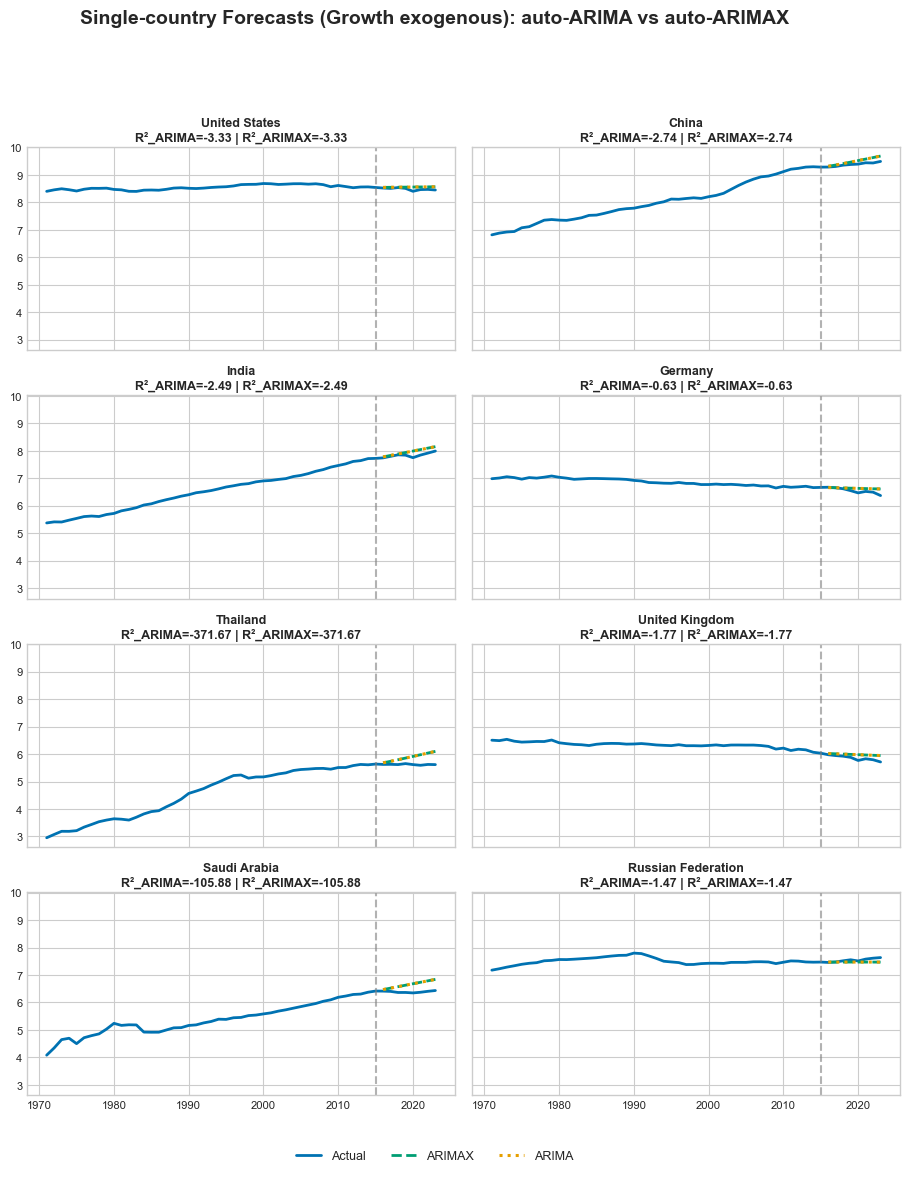

,Country,RMSE_ARIMA,R2_ARIMA,RMSE_ARIMAX,R2_ARIMAX
0,United States,0.086616,-3.331582,0.086616,-3.331582
1,China,0.125345,-2.739966,0.125345,-2.739966
2,India,0.145465,-2.489564,0.145465,-2.489564
3,Germany,0.122570,-0.632723,0.122570,-0.632723
4,Thailand,0.301989,-371.672447,0.301989,-371.672447
5,United Kingdom,0.144699,-1.770088,0.144699,-1.770088
6,Saudi Arabia,0.292860,-105.880459,0.292860,-105.880459
7,Russian Federation,0.093498,-1.473684,0.093498,-1.473684


In [277]:
target_col = "log1p_CO2_total_mt"
sample_countries = ["United States", "China", "India", "Germany","Thailand", "United Kingdom", "Saudi Arabia", "Russian Federation"]
base_exog_cols = ["log1p_GDP_current_usd","log1p_Energy_use_kg_oil_pc","log1p_Population_total"]
other_exog_cols = ["Renewable_energy_pct","LifeExp_years"]

CUTOFF_SINGLE = 2015 

def add_growth_features(df):
    df = df.copy()
    for col in base_exog_cols:
        growth_col = f"{col}_growth"
        if growth_col in df.columns:
            continue
        df[growth_col] = (df.groupby("Country Name")[col].pct_change())
    return df

df_growth = add_growth_features(df)
exog_cols = ["log1p_GDP_current_usd_growth","log1p_Energy_use_kg_oil_pc_growth","log1p_Population_total_growth",] + other_exog_cols

def run_single_country_arima_arimax_enhanced(df,countries=sample_countries,exog_cols=exog_cols,cutoff_year=CUTOFF_SINGLE,target_col=target_col):
    results = []

    fig, axes = plt.subplots(4, 2, figsize=(10, 12),sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, country in zip(axes, countries):
        df_c = (df[df["Country Name"] == country].sort_values("Year").dropna(subset=exog_cols + [target_col]))

        if df_c.empty:
            ax.set_title(f"{country}\n(no data after dropna)", fontsize=9)
            ax.axis("off")
            continue

        train_c = df_c[df_c["Year"] <= cutoff_year]
        test_c  = df_c[df_c["Year"] >  cutoff_year]

        if len(test_c) < 3 or len(train_c) < 15:
            ax.plot(df_c["Year"], df_c[target_col],color="#0072B2", linewidth=2, label="Actual")
            ax.set_title(f"{country}\n(not enough data for test)",fontsize=9, weight="bold")
            continue

        y_train = train_c[target_col].values
        y_test  = test_c[target_col].values
        X_train = train_c[exog_cols].values
        X_test  = test_c[exog_cols].values

        # auto-ARIMA
        arima_model = auto_arima(
            y_train,
            seasonal=False,
            stepwise=False,     
            max_p=6, max_q=6,
            max_order=None,
            n_jobs=-1,
            information_criterion="bic",
            error_action="ignore",
            suppress_warnings=True,
            trace=False)
        y_pred_arima = arima_model.predict(n_periods=len(y_test))

        rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
        r2_arima   = r2_score(y_test, y_pred_arima)

        # auto-ARIMAX (with exog growth)
        arimax_model = auto_arima(
            y_train,
            exogenous=X_train,
            seasonal=False,
            stepwise=False,
            max_p=6, max_q=6,
            max_order=None,
            n_jobs=-1,
            information_criterion="bic",
            error_action="ignore",
            suppress_warnings=True,
            trace=False)
        y_pred_arimax = arimax_model.predict(n_periods=len(y_test),exogenous=X_test)

        rmse_arimax = np.sqrt(mean_squared_error(y_test, y_pred_arimax))
        r2_arimax   = r2_score(y_test, y_pred_arimax)

        results.append([country,rmse_arima,  r2_arima,rmse_arimax, r2_arimax        ])

        ax.plot(df_c["Year"], df_c[target_col],color="#0072B2", linewidth=2, label="Actual")
        ax.plot(test_c["Year"], y_pred_arimax,"--", color="#009E73", linewidth=2, label="ARIMAX")
        ax.plot(test_c["Year"], y_pred_arima,":",  color="#E69F00", linewidth=2.2, label="ARIMA")
        ax.axvline(cutoff_year, color="gray", linestyle="--", alpha=0.6)
        ax.set_title(f"{country}\nR²_ARIMA={r2_arima:.2f} | R²_ARIMAX={r2_arimax:.2f}",fontsize=9, weight="bold", pad=4)
        ax.tick_params(axis="both", labelsize=8)

    for ax in axes[len(countries):]:
        ax.axis("off")

    fig.suptitle("Single-country Forecasts (Growth exogenous): auto-ARIMA vs auto-ARIMAX",fontsize=14, weight="bold", y=0.98)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,loc="lower center",ncol=3,fontsize=9,frameon=False,bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0.06, 0.05, 0.98, 0.93])
    plt.show()

    summary = pd.DataFrame(results,columns=["Country","RMSE_ARIMA",  "R2_ARIMA","RMSE_ARIMAX", "R2_ARIMAX"])
    return summary

summary_enhanced = run_single_country_arima_arimax_enhanced(df_growth)
summary_enhanced


> ### **Section 2: Machine Learning Models (Global)**

> **Baseline Model (Naïve Baseline)**

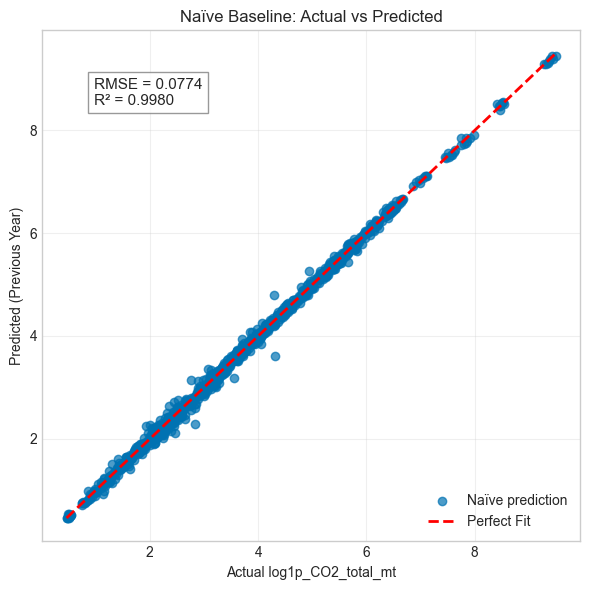

In [278]:
df_naive = df[['Country Code', 'Year', 'log1p_CO2_total_mt']].copy()
df_naive = df_naive.sort_values(['Country Code', 'Year'])
df_naive['prev_CO2'] = df_naive.groupby('Country Code')['log1p_CO2_total_mt'].shift(1)

test_naive = df_naive[df_naive['Year'] > 2015].dropna()
y_true_naive = test_naive['log1p_CO2_total_mt'].values
y_pred_naive = test_naive['prev_CO2'].values

rmse_naive = np.sqrt(mean_squared_error(y_true_naive, y_pred_naive))
r2_naive   = r2_score(y_true_naive, y_pred_naive)

plt.figure(figsize=(6,6))
plt.scatter(y_true_naive, y_pred_naive,alpha=0.7, color="#0072B2",label="Naïve prediction")
plt.plot([y_true_naive.min(), y_true_naive.max()],[y_true_naive.min(), y_true_naive.max()],"r--", linewidth=2, label="Perfect Fit")

plt.xlabel("Actual log1p_CO2_total_mt")
plt.ylabel("Predicted (Previous Year)")
plt.title("Naïve Baseline: Actual vs Predicted")

plt.text(
    x=y_true_naive.min() + 0.5,
    y=y_true_naive.max() - 1.0,
    s=f"RMSE = {rmse_naive:.4f}\nR² = {r2_naive:.4f}",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))

plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Baseline Model (Linear Regression)**

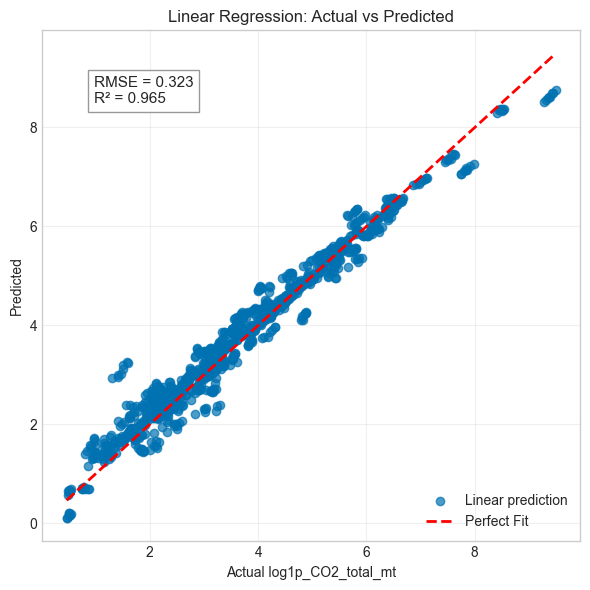

In [279]:
features = ['log1p_GDP_current_usd','log1p_Population_total','log1p_Energy_use_kg_oil_pc','Renewable_energy_pct','LifeExp_years']
target = 'log1p_CO2_total_mt'

CUTOFF_YEAR = 2015
train_df = df[df['Year'] <= CUTOFF_YEAR]
test_df  = df[df['Year'] >  CUTOFF_YEAR]

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, color="#0072B2",label="Linear prediction")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', linewidth=2, label="Perfect Fit") 
plt.xlabel("Actual log1p_CO2_total_mt")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.text(y_test.min()+0.5, y_test.max()-1,f"RMSE = {rmse_lr:.3f}\nR² = {r2_lr:.3f}",fontsize=11,bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Global ML Modeling (Random Forest & XGBoost)**

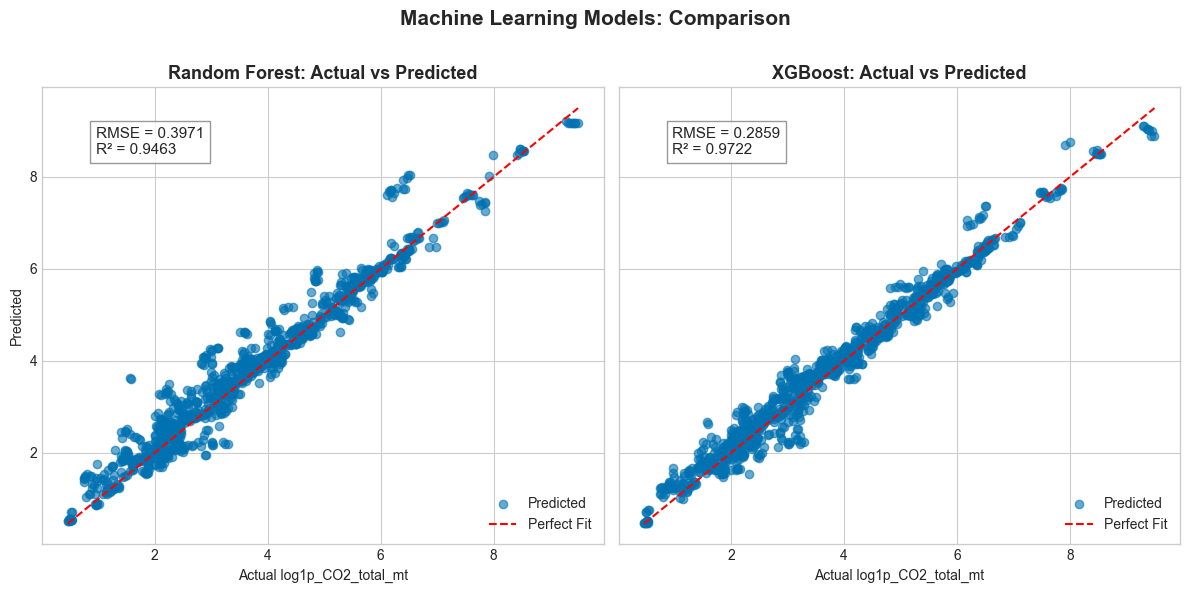

In [280]:
X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]
y_test  = test_df[target]


rf = RandomForestRegressor(n_estimators=300, max_depth=10,min_samples_split=5, min_samples_leaf=3, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,reg_lambda=1.0, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


y_pred_rf  = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

def eval_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, r2

rf_rmse,  rf_r2  = eval_model(y_test, y_pred_rf)
xgb_rmse, xgb_r2 = eval_model(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex=True, sharey=True)

axes[0].scatter(y_test, y_pred_rf, alpha=0.6, color="#0072B2", label="Predicted")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
axes[0].set_title("Random Forest: Actual vs Predicted", fontsize=13, weight='bold')
axes[0].set_xlabel("Actual log1p_CO2_total_mt")
axes[0].set_ylabel("Predicted")
axes[0].legend(fontsize=10)
axes[0].text(x=y_test.min()+0.5, y=y_test.max()-1.0,s=f"RMSE = {rf_rmse:.4f}\nR² = {rf_r2:.4f}",
    fontsize=11, bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))

axes[1].scatter(y_test, y_pred_xgb, alpha=0.6, color="#0072B2", label="Predicted")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit")
axes[1].set_title("XGBoost: Actual vs Predicted", fontsize=13, weight='bold')
axes[1].set_xlabel("Actual log1p_CO2_total_mt")
axes[1].legend(fontsize=10)
axes[1].text(x=y_test.min()+0.5, y=y_test.max()-1.0,s=f"RMSE = {xgb_rmse:.4f}\nR² = {xgb_r2:.4f}",
    fontsize=11, bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))

plt.suptitle("Machine Learning Models: Comparison", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [281]:
y_train_pred_rf  = rf.predict(X_train)
y_train_pred_xgb = xgb.predict(X_train)

def eval_overfit(name, y_train, y_train_pred, y_test, y_test_pred):
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train   = r2_score(y_train, y_train_pred)
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test    = r2_score(y_test, y_test_pred)
    print(f"🔍 {name}")
    print(f"  Train → RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}")
    print(f"  Test  → RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}\n")

eval_overfit("Random Forest", y_train, y_train_pred_rf, y_test, y_pred_rf)
eval_overfit("XGBoost", y_train, y_train_pred_xgb, y_test, y_pred_xgb)

🔍 Random Forest
  Train → RMSE: 0.1230, R²: 0.9956
  Test  → RMSE: 0.3971, R²: 0.9463

🔍 XGBoost
  Train → RMSE: 0.1063, R²: 0.9967
  Test  → RMSE: 0.2859, R²: 0.9722



> **Cross-Validation (CV)**

In [282]:
cutoff_years = [1990, 2000, 2010, 2015]
results = []

for cutoff in cutoff_years:
    train = df[df["Year"] <= cutoff].dropna(subset=features + [target])
    test  = df[(df["Year"] > cutoff) & (df["Year"] <= cutoff + 5)].dropna(subset=features + [target])
    
    if len(test) == 0:
        continue
    
    X_train, y_train = train[features], train[target]
    X_test,  y_test  = test[features],  test[target]
    
    rf = RandomForestRegressor(
        n_estimators=300, max_depth=10,
        min_samples_split=5, min_samples_leaf=3,
        random_state=42, n_jobs=-1)
    
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    rf_r2   = r2_score(y_test, y_pred_rf)
    
    xgb = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42)
    
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_r2   = r2_score(y_test, y_pred_xgb)
    
    results.append([cutoff, rf_rmse, rf_r2, xgb_rmse, xgb_r2])
    
    print(f"Train ≤ {cutoff} | Test {cutoff+1}–{cutoff+5}")
    print(f"  RF   → RMSE={rf_rmse:.3f}, R²={rf_r2:.3f}")
    print(f"  XGB  → RMSE={xgb_rmse:.3f}, R²={xgb_r2:.3f}\n")

results_df = pd.DataFrame(results,columns=["Cutoff_Year", "RF_RMSE", "RF_R2", "XGB_RMSE", "XGB_R2"])
results_df

Train ≤ 1990 | Test 1991–1995
  RF   → RMSE=0.358, R²=0.963
  XGB  → RMSE=0.312, R²=0.972

Train ≤ 2000 | Test 2001–2005
  RF   → RMSE=0.280, R²=0.977
  XGB  → RMSE=0.243, R²=0.982

Train ≤ 2010 | Test 2011–2015
  RF   → RMSE=0.363, R²=0.958
  XGB  → RMSE=0.277, R²=0.975

Train ≤ 2015 | Test 2016–2020
  RF   → RMSE=0.343, R²=0.960
  XGB  → RMSE=0.248, R²=0.979



,Cutoff_Year,RF_RMSE,RF_R2,XGB_RMSE,XGB_R2
0,1990,0.358279,0.963233,0.311802,0.972153
1,2000,0.279552,0.976523,0.243082,0.982249
2,2010,0.362623,0.957788,0.276615,0.975437
3,2015,0.342664,0.960330,0.248150,0.979196


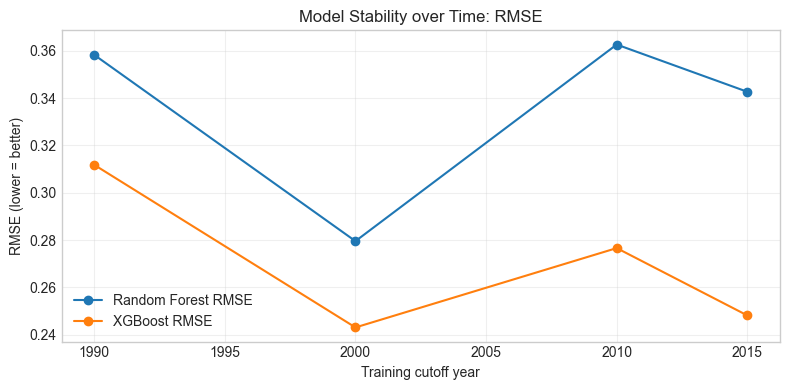

In [283]:
plt.figure(figsize=(8,4))
plt.plot(results_df["Cutoff_Year"], results_df["RF_RMSE"],
         "o-", label="Random Forest RMSE")
plt.plot(results_df["Cutoff_Year"], results_df["XGB_RMSE"],
         "o-", label="XGBoost RMSE")
plt.xlabel("Training cutoff year")
plt.ylabel("RMSE (lower = better)")
plt.title("Model Stability over Time: RMSE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

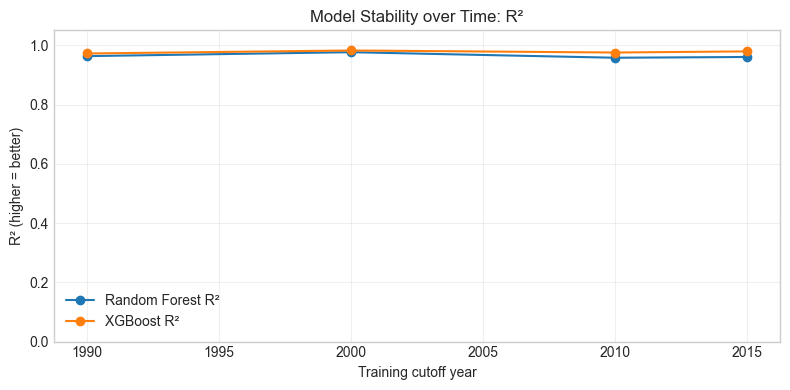

In [284]:
plt.figure(figsize=(8,4))
plt.plot(results_df["Cutoff_Year"], results_df["RF_R2"],
         "o-", label="Random Forest R²")
plt.plot(results_df["Cutoff_Year"], results_df["XGB_R2"],
         "o-", label="XGBoost R²")
plt.xlabel("Training cutoff year")
plt.ylabel("R² (higher = better)")
plt.ylim(0, 1.05)
plt.title("Model Stability over Time: R²")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> ### **Section 3: Tier-Aware Modeling & Feature Importance**

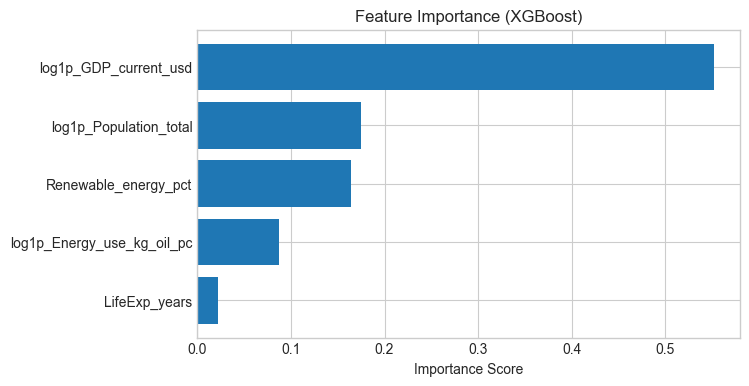

In [285]:
importance = pd.DataFrame({'Feature': features,'Importance': xgb.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure(figsize=(7,4))
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

> **Tier-Aware Modeling (High / Medium / Low emitters)**

In [286]:
if "Emission_Tier" not in df.columns:
    mean_recent = (df[df["Year"].between(2018, 2022)]
                   .groupby("Country Code")["CO2_total_mt"]
                   .mean())
    quantiles = mean_recent.quantile([0.33, 0.67]).values
    def assign_tier(x):
        if x <= quantiles[0]:
            return "Low"
        elif x <= quantiles[1]:
            return "Medium"
        else:
            return "High"
    tier_map = mean_recent.apply(assign_tier)
    df["Emission_Tier"] = df["Country Code"].map(tier_map)

In [287]:
for t in df["Emission_Tier"].unique():
    countries = df[df["Emission_Tier"]==t]["Country Name"].unique()
    print(f"\n{t} Tier ({len(countries)} countries):")
    print(", ".join(sorted(countries[:10])) + ("..." if len(countries) > 10 else ""))


Low Tier (47 countries):
Albania, Armenia, Benin, Botswana, Brunei Darussalam, Burkina Faso, Cameroon, Chad, Congo, Dem. Rep., Congo, Rep....

High Tier (47 countries):
Algeria, Argentina, Australia, Bangladesh, Belgium, Brazil, Canada, Chile, China, Colombia...

Medium Tier (49 countries):
Angola, Austria, Azerbaijan, Bahrain, Belarus, Bolivia, Bosnia and Herzegovina, Bulgaria, Cambodia, Cote d'Ivoire...


In [ ]:
features = ['log1p_GDP_current_usd','log1p_Population_total','log1p_Energy_use_kg_oil_pc','Renewable_energy_pct','LifeExp_years']
target = 'log1p_CO2_total_mt'
tiers = ['High', 'Medium', 'Low']
results = []

for t in tiers:
    df_t = df[df['Emission_Tier'] == t].dropna(subset=features + [target])
    
    train_t = df_t[df_t['Year'] <= 2015]
    test_t  = df_t[df_t['Year'] > 2015]

    X_train, y_train = train_t[features], train_t[target]
    X_test,  y_test  = test_t[features],  test_t[target]

    model = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,subsample=0.8, colsample_bytree=0.8,reg_alpha=0.1, reg_lambda=1.0, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results.append([t, rmse, r2])

tier_results = pd.DataFrame(results, columns=["Emission_Tier", "RMSE", "R2"])
print(tier_results)


  Emission_Tier      RMSE        R2
0          High  0.325287  0.911795
1        Medium  0.205272  0.797678
2           Low  0.233056  0.818036


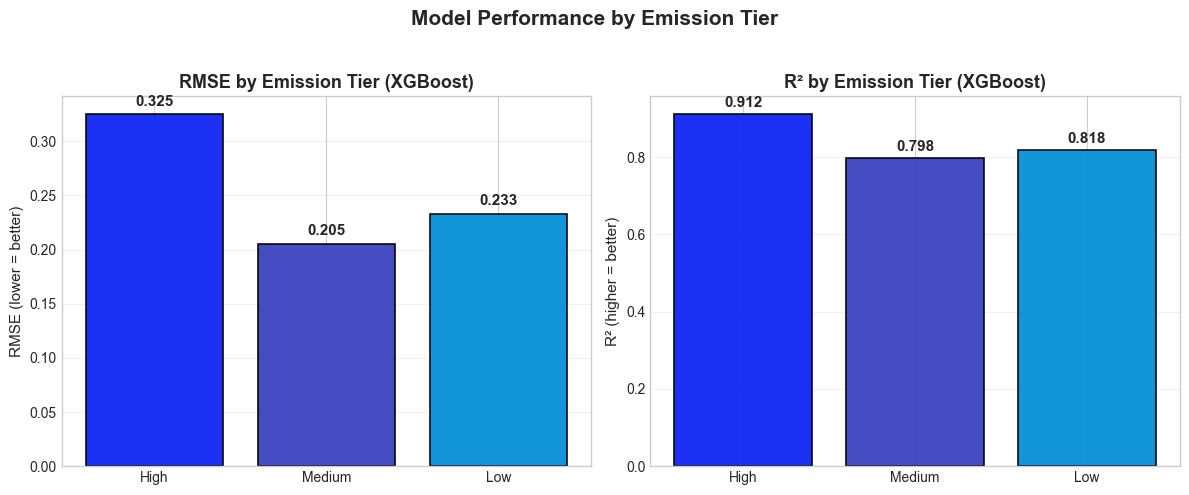

In [297]:
colors = ["#0F26F4", "#3C43BF", "#0691D7"]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

bars1 = axes[0].bar(tier_results["Emission_Tier"],tier_results["RMSE"],color=colors,edgecolor="black",linewidth=1.2,alpha=0.95)
axes[0].set_title("RMSE by Emission Tier (XGBoost)", fontsize=13, weight='bold')
axes[0].set_ylabel("RMSE (lower = better)", fontsize=11)
axes[0].grid(alpha=0.3, axis='y')


for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.005,f"{yval:.3f}", ha='center', va='bottom',fontsize=11, weight='bold')

bars2 = axes[1].bar(tier_results["Emission_Tier"],tier_results["R2"],color=colors,edgecolor="black",linewidth=1.2,alpha=0.95)
axes[1].set_title("R² by Emission Tier (XGBoost)", fontsize=13, weight='bold')
axes[1].set_ylabel("R² (higher = better)", fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 0.01,f"{yval:.3f}", ha='center', va='bottom',fontsize=11, weight='bold')

plt.suptitle("Model Performance by Emission Tier", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


---- Feature importance: High Tier ----
                      Feature  Importance
4               LifeExp_years    0.024666
3        Renewable_energy_pct    0.074373
2  log1p_Energy_use_kg_oil_pc    0.167672
1      log1p_Population_total    0.235130
0       log1p_GDP_current_usd    0.498159

---- Feature importance: Medium Tier ----
                      Feature  Importance
4               LifeExp_years    0.052239
0       log1p_GDP_current_usd    0.095747
1      log1p_Population_total    0.104079
3        Renewable_energy_pct    0.188337
2  log1p_Energy_use_kg_oil_pc    0.559598

---- Feature importance: Low Tier ----
                      Feature  Importance
4               LifeExp_years    0.060301
1      log1p_Population_total    0.165899
2  log1p_Energy_use_kg_oil_pc    0.176636
0       log1p_GDP_current_usd    0.217446
3        Renewable_energy_pct    0.379717


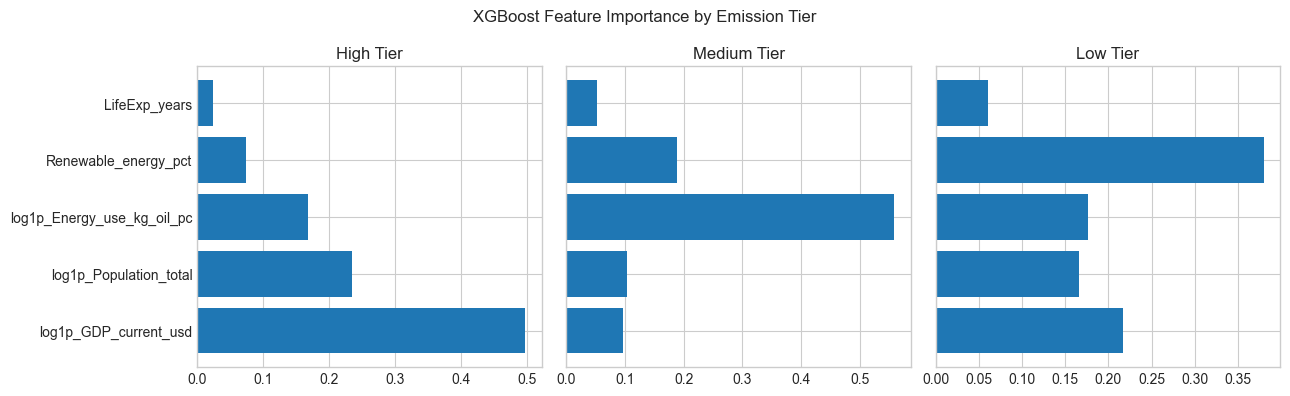

In [290]:
models_by_tier = {}
importances_by_tier = {}

for t in tiers:
    df_t = df[df['Emission_Tier'] == t].dropna(subset=features + [target])

    train_t = df_t[df_t['Year'] <= 2015]
    test_t  = df_t[df_t['Year'] > 2015]

    X_train, y_train = train_t[features], train_t[target]

    model = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,subsample=0.8, colsample_bytree=0.8,reg_alpha=0.1, reg_lambda=1.0, random_state=42)
    model.fit(X_train, y_train)
    models_by_tier[t] = model  

    fi = pd.DataFrame({'Feature': features,'Importance': model.feature_importances_}).sort_values('Importance', ascending=True)

    importances_by_tier[t] = fi
    print(f"\n---- Feature importance: {t} Tier ----")
    print(fi)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, t in zip(axes, tiers):
    fi = importances_by_tier[t]
    ax.barh(fi['Feature'], fi['Importance'])
    ax.set_title(f'{t} Tier')
    ax.invert_yaxis()
plt.suptitle('XGBoost Feature Importance by Emission Tier')
plt.tight_layout()
plt.show()

> ### **Section 4: Forecast 2030 (Global & Tier-specific)**

In [291]:
LAST_YEAR = df["Year"].max() 

train_full = df[df["Year"] <= LAST_YEAR].dropna(subset=features+[target])
X_train_full = train_full[features]
y_train_full = train_full[target]

xgb_final = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,subsample=0.8, colsample_bytree=0.8,reg_alpha=0.1, reg_lambda=1.0,random_state=42)
xgb_final.fit(X_train_full, y_train_full)

print("Final global XGB model trained up to year:", LAST_YEAR)

Final global XGB model trained up to year: 2023


In [ ]:
FUTURE_YEARS = list(range(LAST_YEAR + 1, 2031))

def make_future_scenario(df, years_back=5):
    rows = []

    for cc, g in df.groupby("Country Code"):
        g = g.sort_values("Year")
        g_recent = g.tail(years_back)

        if len(g_recent) < 2:
            continue 

        last_year = g_recent["Year"].iloc[-1]

        slopes = {}
        last_vals = {}

        for col in [
            "log1p_GDP_current_usd",
            "log1p_Population_total",
            "log1p_Energy_use_kg_oil_pc",
            "Renewable_energy_pct",
            "LifeExp_years"]:
            y0 = g_recent[col].iloc[0]
            y1 = g_recent[col].iloc[-1]
            t0 = g_recent["Year"].iloc[0]
            t1 = g_recent["Year"].iloc[-1]
            slope = (y1 - y0) / (t1 - t0)
            slopes[col] = slope
            last_vals[col] = y1

        country_name = g["Country Name"].iloc[-1]
        tier = g["Emission_Tier"].iloc[-1] if "Emission_Tier" in g.columns else None

        for y in FUTURE_YEARS:
            step = y - last_year
            feat_vals = {}
            for col in last_vals:
                val = last_vals[col] + slopes[col] * step
                if col == "Renewable_energy_pct":
                    val = max(0, min(100, val)) 
                feat_vals[col] = val

            row = {
                "Country Code": cc,
                "Country Name": country_name,
                "Year": y,
                "Emission_Tier": tier,
                **feat_vals,}
            rows.append(row)

    future_df = pd.DataFrame(rows)
    return future_df

future_features = make_future_scenario(df, years_back=5)
future_features

,Country Code,Country Name,Year,Emission_Tier,log1p_GDP_current_usd,log1p_Population_total,log1p_Energy_use_kg_oil_pc,Renewable_energy_pct,LifeExp_years
0,AGO,Angola,2024,Medium,25.209432,17.451329,6.053660,53.375,65.00850
1,AGO,Angola,2025,Medium,25.254417,17.483011,6.057297,53.850,65.40000
2,AGO,Angola,2026,Medium,25.299402,17.514693,6.060934,54.325,65.79150
3,AGO,Angola,2027,Medium,25.344387,17.546376,6.064572,54.800,66.18300
4,AGO,Angola,2028,Medium,25.389372,17.578058,6.068209,55.275,66.57450
...,...,...,...,...,...,...,...,...,...
996,ZWE,Zimbabwe,2026,Low,24.521330,16.659942,6.042476,83.450,64.06125
997,ZWE,Zimbabwe,2027,Low,24.600040,16.676864,6.045137,83.800,64.49000
998,ZWE,Zimbabwe,2028,Low,24.678749,16.693785,6.047798,84.150,64.91875
999,ZWE,Zimbabwe,2029,Low,24.757458,16.710707,6.050459,84.500,65.34750


In [293]:
X_future = future_features[features]
future_pred_log = xgb_final.predict(X_future)

future_features["pred_log1p_CO2_total_mt"] = future_pred_log
future_features["pred_CO2_total_mt"] = np.expm1(future_pred_log)

In [294]:
actual = df[["Country Code", "Country Name", "Year", "Emission_Tier", "CO2_total_mt"]].copy()
actual["Source"] = "Actual"

forecast = future_features[["Country Code", "Country Name", "Year", "Emission_Tier", "pred_CO2_total_mt"]].copy()
forecast = forecast.rename(columns={"pred_CO2_total_mt": "CO2_total_mt"})
forecast["Source"] = "Forecast"

combined = pd.concat([actual, forecast], ignore_index=True)

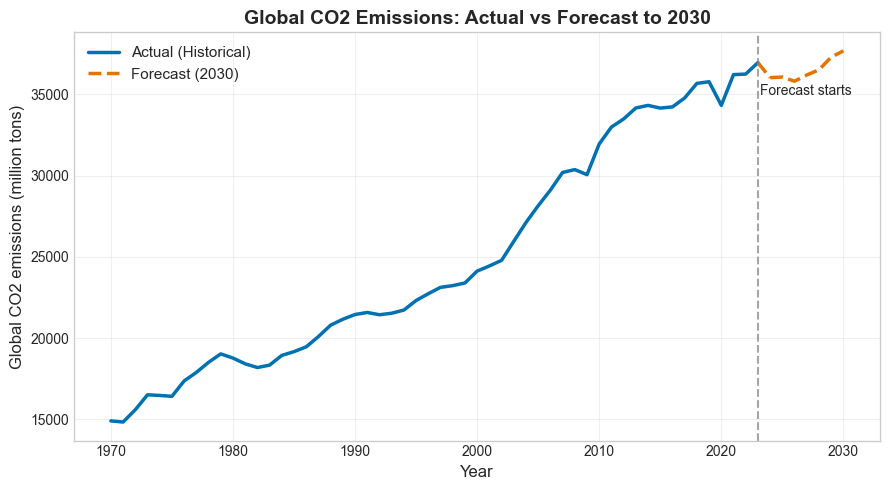

In [295]:
world_series = (combined.groupby(["Year", "Source"])["CO2_total_mt"].sum().reset_index())

plt.figure(figsize=(9,5))
world_actual = world_series[world_series["Source"]=="Actual"]
world_forecast = world_series[world_series["Source"]=="Forecast"]

plt.plot(world_actual["Year"], world_actual["CO2_total_mt"],label="Actual (Historical)", color="#0072B2", linewidth=2.5)

plt.plot(world_forecast["Year"], world_forecast["CO2_total_mt"],"--", label="Forecast (2030)", color="#E67300", linewidth=2.5)

plt.plot([world_actual["Year"].iloc[-1], world_forecast["Year"].iloc[0]],[world_actual["CO2_total_mt"].iloc[-1], world_forecast["CO2_total_mt"].iloc[0]],
    color="#E67300", linestyle="--", linewidth=2.5)

plt.axvline(LAST_YEAR, color="gray", linestyle="--", alpha=0.7)
plt.text(LAST_YEAR+0.2, plt.ylim()[1]*0.90, "Forecast starts")

plt.xlabel("Year", fontsize=12)
plt.ylabel("Global CO2 emissions (million tons)", fontsize=12)
plt.title("Global CO2 Emissions: Actual vs Forecast to 2030", fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


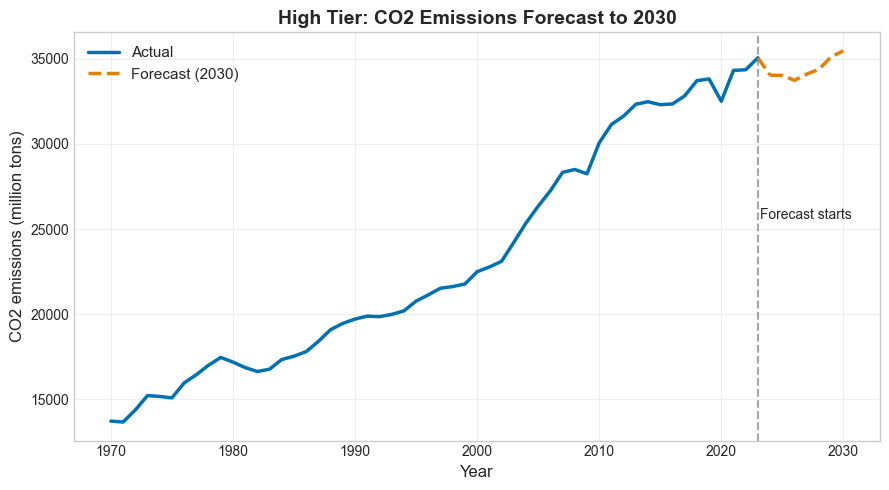

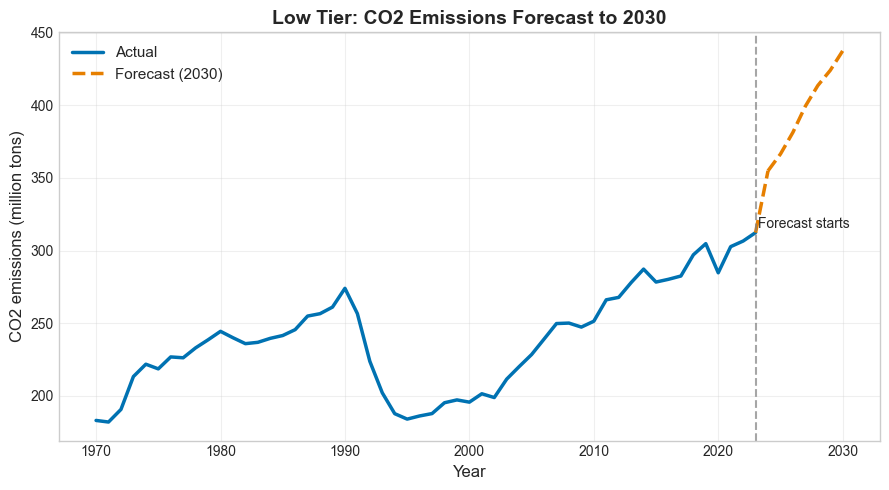

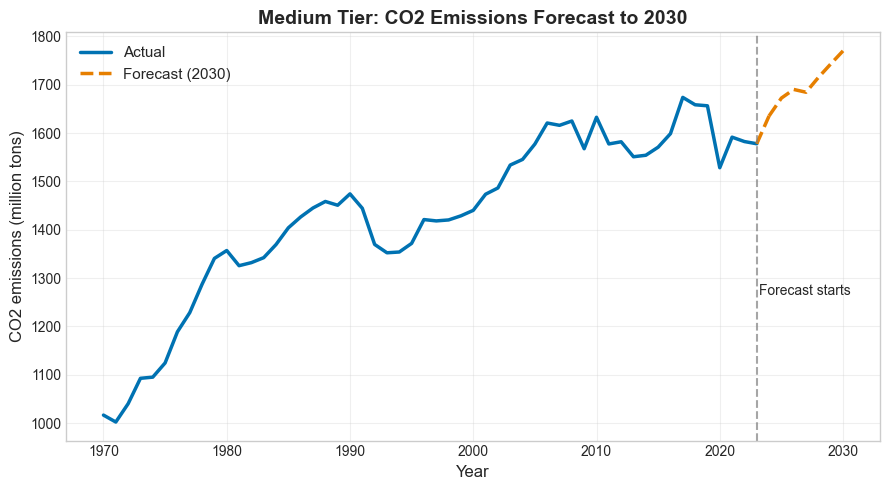

In [296]:
tier_series = (combined.groupby(["Year", "Emission_Tier", "Source"])["CO2_total_mt"].sum().reset_index())

for t in sorted(tier_series["Emission_Tier"].dropna().unique()):
    data_t = tier_series[tier_series["Emission_Tier"] == t]
    act_t  = data_t[data_t["Source"] == "Actual"]
    fc_t   = data_t[data_t["Source"] == "Forecast"]

    plt.figure(figsize=(9,5))
    plt.plot(act_t["Year"], act_t["CO2_total_mt"],label="Actual", color="#0072B2", linewidth=2.5)
    plt.plot(fc_t["Year"], fc_t["CO2_total_mt"],"--", label="Forecast (2030)", color="#E67F00", linewidth=2.5)

    if not act_t.empty and not fc_t.empty:
        plt.plot([act_t["Year"].iloc[-1], fc_t["Year"].iloc[0]],[act_t["CO2_total_mt"].iloc[-1], fc_t["CO2_total_mt"].iloc[0]],
            color="#E67F00", linestyle="--", linewidth=2.5)

    plt.axvline(LAST_YEAR, color="gray", linestyle="--", alpha=0.7)
    plt.text(LAST_YEAR+0.2, plt.ylim()[1]*0.70, "Forecast starts")

    plt.title(f"{t} Tier: CO2 Emissions Forecast to 2030", fontsize=14, weight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("CO2 emissions (million tons)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Discussion & Insights
- **Statistical Baselines:** ARIMA and ARIMAX models show poor fit (negative R²), indicating that CO₂ dynamics are not well captured by simple autoregressive structures.  
- **Machine Learning Models:** Random Forest and XGBoost outperform statistical models with R² ≈ 0.95–0.97, demonstrating stronger ability to integrate socio-economic and energy factors.  
- **Tier-based Results:** XGBoost accuracy is highest for High-emission countries, while interpretability improves through tier-level feature importance analysis.  
- **Forecast Implications:** Global CO₂ emissions are projected to increase from ~36,000 Mt in 2023 to ~39,500 Mt by 2030 (+9%), mainly driven by GDP and energy-use growth.  
- **Conclusion:** The proposed ML-based framework provides an interpretable yet extensible forecasting pipeline for global emission studies.